<a href="https://colab.research.google.com/github/sofiagracereina/-sofia_INFO5731_Fall2024-/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mlxtend
import networkx as nx

!pip install pandas matplotlib mlxtend networkx

### Data Loading

Please ensure `bread_basket.csv` is uploaded to your Colab environment or update the `file_path` variable below to its correct location.

You can upload the file by clicking on the folder icon on the left sidebar -> 'Files' tab -> 'Upload to session storage' icon.

In [15]:
from google.colab import files

file_path = 'bread_basket.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_path}'")
except FileNotFoundError:
    print(f"Error: '{file_path}' not found. Please upload the file or correct the path.")
    df = None # Set df to None to indicate failure to load

if df is not None:
    display(df.head())

Successfully loaded 'bread_basket.csv'


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


In [ ]:
# write your answer here

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import mlxtend
import networkx as nx

df['item'] = df['item'].astype('category')
df['period_day'] = df['period_day'].astype('category')
df['weekday_weekend'] = df['weekday_weekend'].astype('category')
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed', dayfirst=True)
df['time'] = df['date_time'].dt.time

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   transaction      20507 non-null  int64         
 1   item             20507 non-null  category      
 2   date_time        20507 non-null  datetime64[ns]
 3   time             20507 non-null  object        
 4   period_day       20507 non-null  category      
 5   weekday_weekend  20507 non-null  category      
dtypes: category(3), datetime64[ns](1), int64(1), object(1)
memory usage: 544.0+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import mlxtend
import networkx as nx

df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

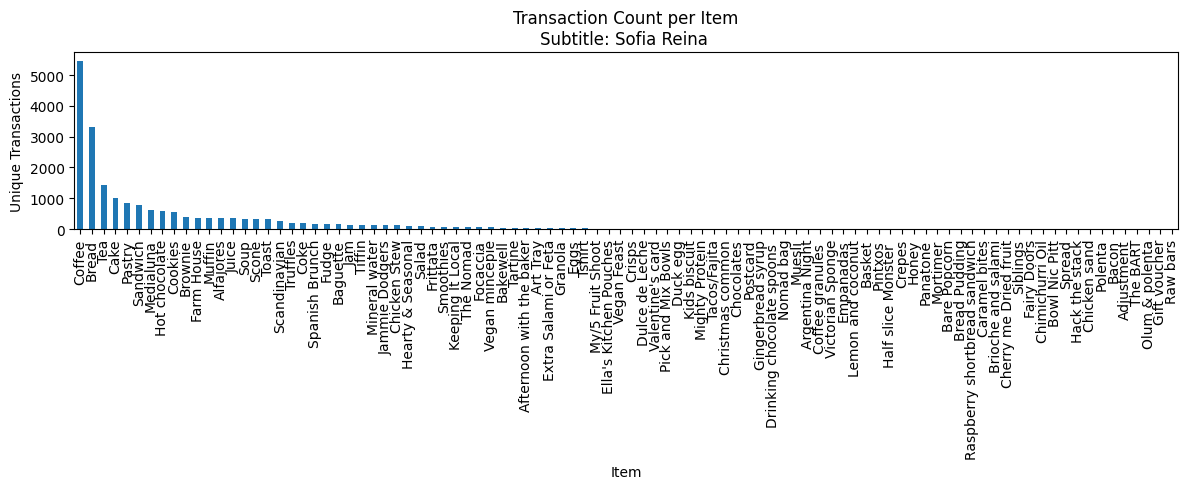

In [18]:
# c) Bar plot of transaction counts per item
subtitle = "Sofia Reina "  # <-- EDIT THIS (Replace with your actual name)
item_counts = df['item'].value_counts().sort_values(ascending=False)

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [22]:
items_to_report = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
for item in items_to_report:
    count = df[df['item'] == item]['item'].count()
    print(f"Count for {item}: {count}")

Count for Coffee: 5471
Count for Tea: 1435
Count for Alfajores: 369
Count for Juice: 369
Count for Chicken Stew: 123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.2) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [32]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

# Group items by transaction
transactions = df.groupby('transaction')['item'].apply(list).values

# One-hot encode the transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

# Apply FP-Growth algorithm with a lower min_support
min_support = 0.02
frequent_itemsets = fpgrowth(df_transactions, min_support=min_support, use_colnames=True)

print(f"Frequent Itemsets (min_support={min_support}):")
display(frequent_itemsets.sort_values(by='support', ascending=False))

Frequent Itemsets (min_support=0.02):


,support,itemsets
5,0.478394,(Coffee)
0,0.327205,(Bread)
8,0.142631,(Tea)
12,0.103856,(Cake)
19,0.090016,"(Coffee, Bread)"
6,0.086107,(Pastry)
13,0.071844,(Sandwich)
7,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
28,0.054728,"(Cake, Coffee)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [36]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='confidence', ascending=False))

if rules.empty: print("No rules found.")

,antecedents,consequents,support,confidence,lift
17,(Toast),(Coffee),0.023666,0.704403,1.472431
6,(Medialuna),(Coffee),0.035182,0.569231,1.189878
4,(Pastry),(Coffee),0.047544,0.552147,1.154168
10,(Juice),(Coffee),0.020602,0.534247,1.116750
16,(Sandwich),(Coffee),0.038246,0.532353,1.112792
11,(Cake),(Coffee),0.054728,0.526958,1.101515
3,(Cookies),(Coffee),0.028209,0.518447,1.083723
2,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311
7,(Tea),(Coffee),0.049868,0.349630,0.730840
5,(Pastry),(Bread),0.029160,0.338650,1.034977


In [37]:
# Calculate metrics for the specific rule {Coffee, Cake} => {Bread}

# Support(Coffee, Cake, Bread)
support_coffee_cake_bread = df_transactions[(df_transactions['Coffee'] == True) &
                                            (df_transactions['Cake'] == True) &
                                            (df_transactions['Bread'] == True)].shape[0] / len(df_transactions)

# Support(Coffee, Cake)
support_coffee_cake = df_transactions[(df_transactions['Coffee'] == True) &
                                      (df_transactions['Cake'] == True)].shape[0] / len(df_transactions)

# Support(Bread)
support_bread = df_transactions[df_transactions['Bread'] == True].shape[0] / len(df_transactions)

# Confidence(Coffee, Cake => Bread)
confidence_coffee_cake_bread = support_coffee_cake_bread / support_coffee_cake if support_coffee_cake != 0 else 0

# Lift(Coffee, Cake => Bread)
lift_coffee_cake_bread = confidence_coffee_cake_bread / support_bread if support_bread != 0 else 0

print(f"Support({{'Coffee', 'Cake', 'Bread'}}): {support_coffee_cake_bread:.4f}")
print(f"Support({{'Coffee', 'Cake'}}): {support_coffee_cake:.4f}")
print(f"Support({{'Bread'}}): {support_bread:.4f}")
print(f"Confidence({{'Coffee', 'Cake'}} => {{'Bread'}}): {confidence_coffee_cake_bread:.4f}")
print(f"Lift({{'Coffee', 'Cake'}} => {{'Bread'}}): {lift_coffee_cake_bread:.4f}")

Support({'Coffee', 'Cake', 'Bread'}): 0.0100
Support({'Coffee', 'Cake'}): 0.0547
Support({'Bread'}): 0.3272
Confidence({'Coffee', 'Cake'} => {'Bread'}): 0.1834
Lift({'Coffee', 'Cake'} => {'Bread'}): 0.5605


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (write your answer here)

>